<a href="https://colab.research.google.com/github/Paulo123213/MineriaDatos/blob/TomasOrtega/prueba3mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
##  FASE 1 — Comprensión del Negocio
### 1.1 Contexto del problema
El dataset proviene de Kaggle (TETRIO Tetra League Historical Data) y contiene registros históricos de partidas clasificatorias. Cada fila representa un jugador con sus métricas promedio de desempeño y su rango asignado. Incluye variables numéricas continuas como APM, PPS y Glicko, y la variable categórica ordinal tlrank que representa el rango textual del jugador.

### 1.2 Objetivo del negocio
Determinar qué métricas de desempeño en partida (APM, PPS, APP) son los mejores predictores del rango de un jugador, y construir un modelo capaz de estimarlo.

### 1.3 Criterio de éxito
- Correlación entre APM y rango > 0.70  
- Modelo de predicción con R² > 0.70

---
##  FASE 2 — Comprensión de los datos
TETR.IO es un juego de puzzles competitivo (tipo Tetris) con un sistema de ranking. El rango de un jugador refleja su habilidad relativa frente a otros en modalidad 1 vs 1.

##  Diccionario de Datos
## Aqui explicamos el significado de cada dato de la DF
| Columna        | Tipo de Dato | Descripción                                           |
| :------------- | :----------- | :---------------------------------------------------- |
| `id`           | `object`     |  `id del jugador`                                                     |
| `username`     | `object`     |         `Nombre del jugador`                                              |
| `tlrank`       | `object`     |     `Rango del jugador en la categoria de 1 vs 1`                                                  |
| `apm`          | `float64`    |   `Ataques por minuto `                                                    |
| `pps`          | `float64`    |    `Piezas por minuto`                                                   |
| `raw_app`      | `float64`    |       `Ataques por pieza siendo la cantidad de ataques realizados con una pieza`                                                |
| `adjusted_app` | `float64`    |       `Ataques por pieza promediado entre partidas`                                                |
| `tr`           | `float64`    |   `Rango del jugador`                                                    |
| `glicko`       | `float64`    |      `Representacion numerica del rango del jugador `                                                 |
| `rd`           | `int64`      |   `Rating deviaton `                                                    |
| `gamesplayed`  | `int64`      |    `Cantidad de juegos por el jugador`                                                   |
| `gameswon`     | `int64`      |     `Juegos ganados por el jugador`                                                        
| `rank_num`     | `float64`    | `Numero de ranking mundial` |

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("limguowei/tetrio-tetra-league-historical-data")

print("Path to dataset files:", path)


100%|██████████| 1.01G/1.01G [00:14<00:00, 75.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/limguowei/tetrio-tetra-league-historical-data/versions/3


In [4]:
df = pd.read_csv(os.path.join(path, 'tl-calculated-delta-table.csv'))

In [5]:
# List the contents of the downloaded directory to find the CSV file
print("Contents of the downloaded directory:")
for filename in os.listdir(path):
    print(filename)

Contents of the downloaded directory:
tl-calculated-delta-table.csv
tl-delta-table-v2.0.csv


---
##  FASE 3 — Preparacion de los datos
En esta fase se limpia y transforma el dataset para dejarlo listo para el modelado. Se eliminan columnas irrelevantes, se normaliza la variable de rango, se codifica de forma ordinal y se convierten los tipos de datos. Finalmente se eliminan los registros con valores nulos en las columnas de análisis.



#3.1 Depuracion de los datos

Aquí realizamos las primeras etapas de limpieza del DataFrame `df_clean`.

*   **Eliminación de Columnas**: Se eliminan columnas que no son relevantes para el análisis actual o que ya se han verificado que tienen valores constantes o información duplicada (`vs`, `raw_eff`, `adjusted_eff`, `verified`).
*   **Normalización de Rangos**: La columna `tlrank` se normaliza convirtiendo los valores a minúsculas y eliminando espacios para asegurar consistencia.

In [6]:
df_clean = pd.read_csv(os.path.join(path, 'tl-calculated-delta-table.csv'))

In [7]:
df_clean = df_clean.drop(columns=['vs', 'raw_eff', 'adjusted_eff', 'verified'])

In [8]:
df_clean['tlrank'] = df_clean['tlrank'].astype(str).str.strip().str.lower()

In [9]:
df_clean.head(10)

,id,username,tlrank,apm,pps,raw_app,adjusted_app,tr,glicko,rd,gamesplayed,gameswon,deltadate
0,5e484c3eadfab42c76f0af36,vince,x,139.63,3.44,0.676502,0.452287,24546.0,2553.0,85,31,26,2020-04-08 17:42:00
1,5e3f6ebe3dacc16dbc4dd6aa,doremy,x,116.71,2.79,0.697192,0.465930,24266.0,2419.0,71,100,86,2020-04-08 17:42:00
2,5e40825a4be6907ad7eab03d,sm999,u,128.92,3.32,0.647189,0.432719,24239.0,2409.0,72,72,64,2020-04-08 17:42:00
3,5e3d58e92445dd5207770ca5,wumbo,u,93.24,2.37,0.655696,0.438045,24213.0,2401.0,75,74,67,2020-04-08 17:42:00
4,5e4f0ad196a8426ec442746e,qmk,u,121.82,2.92,0.695320,0.464754,24137.0,2376.0,76,44,39,2020-04-08 17:42:00
5,5e40a2b74be6907ad7eab292,cheep,u,109.59,2.88,0.634201,0.423902,24012.0,2345.0,95,20,14,2020-04-08 17:42:00
6,5e697bbf77aba60f95fb38da,firestorm,u,119.78,2.94,0.679025,0.453900,23948.0,2320.0,70,64,49,2020-04-08 17:42:00
7,5e381f4c456244768a097502,zack101155,u,104.13,2.51,0.691434,0.462049,23638.0,2251.0,79,38,35,2020-04-08 17:42:00
8,5e436daf368a5d2489fbf848,star,u,107.18,2.74,0.651946,0.435760,23570.0,2243.0,99,24,24,2020-04-08 17:42:00
9,5e4db4eff5d51a6eb7ec0bb6,zerot,u,115.67,3.05,0.632077,0.422605,23563.0,2238.0,87,25,22,2020-04-08 17:42:00


In [10]:
df_clean.isna().sum()

,0
id,0
username,0
tlrank,0
apm,0
pps,0
raw_app,0
adjusted_app,0
tr,0
glicko,0
rd,0


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 17 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   vs            float64
 6   raw_eff       float64
 7   adjusted_eff  float64
 8   raw_app       float64
 9   adjusted_app  float64
 10  tr            float64
 11  glicko        float64
 12  rd            int64  
 13  gamesplayed   int64  
 14  gameswon      int64  
 15  verified      float64
 16  deltadate     object 
dtypes: float64(10), int64(3), object(4)
memory usage: 1.0+ GB
None


#3.1 Encoding

Se convierte la variable categórica ordinal tlrank a un valor numérico entero mediante un diccionario de mapeo, donde 0 representa el rango más bajo (Z) y 17 el más alto (X). Luego se fuerza la conversión numérica de todas las columnas de análisis y se eliminan las filas con valores nulos resultantes.

In [12]:
rank_mapping = {
    'x': 17, 'u': 16, 'ss': 15, 's+': 14, 's': 13, 's-': 12,
    'a+': 11, 'a': 10, 'a-': 9, 'b+': 8, 'b': 7, 'b-': 6,
    'c+': 5, 'c': 4, 'c-': 3, 'd+': 2, 'd': 1, 'z': 0
}
df_clean['rank_num'] = df_clean['tlrank'].map(rank_mapping)

In [13]:
cols_analisis = ['rank_num', 'apm', 'pps', 'raw_app', 'adjusted_app']
for col in cols_analisis:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [14]:
df_final = df_clean[cols_analisis].dropna()

In [15]:
print(f"Registros listos para el análisis: {len(df_final)}")
print(df_final.head())

Registros listos para el análisis: 8177602
   rank_num     apm   pps   raw_app  adjusted_app
0        17  139.63  3.44  0.676502      0.452287
1        17  116.71  2.79  0.697192      0.465930
2        16  128.92  3.32  0.647189      0.432719
3        16   93.24  2.37  0.655696      0.438045
4        16  121.82  2.92  0.695320      0.464754


## Fase 2 continuacion

## Análisis Exploratorio de los datos

El boxplot por rango permite detectar valores atípicos en APM. En rangos altos (S, SS, U, X) se observan outliers con APM extremadamente elevado, lo cual es esperable dado el nivel competitivo. Estos valores se conservan ya que son datos reales de jugadores de élite.

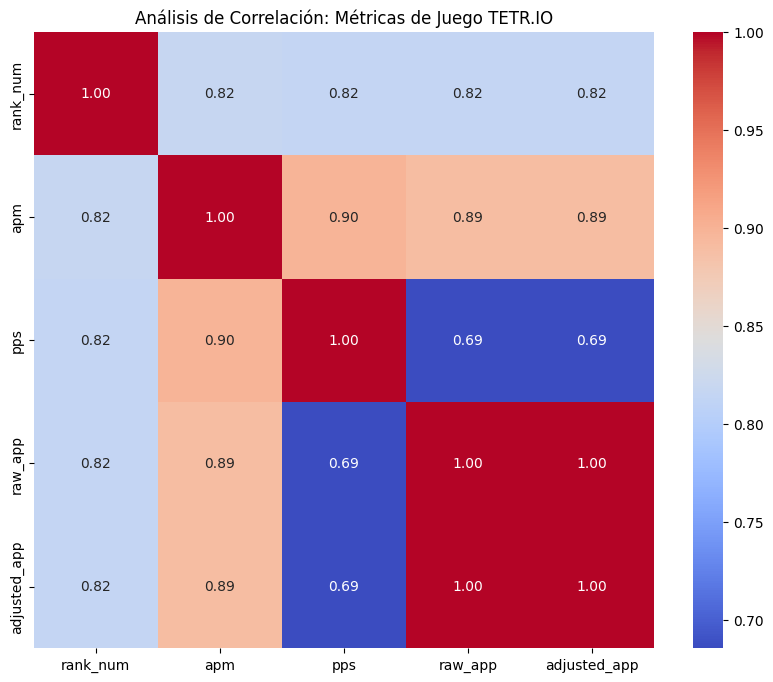

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 8))
matriz_corr = df_final.corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Análisis de Correlación: Métricas de Juego TETR.IO')
plt.show()

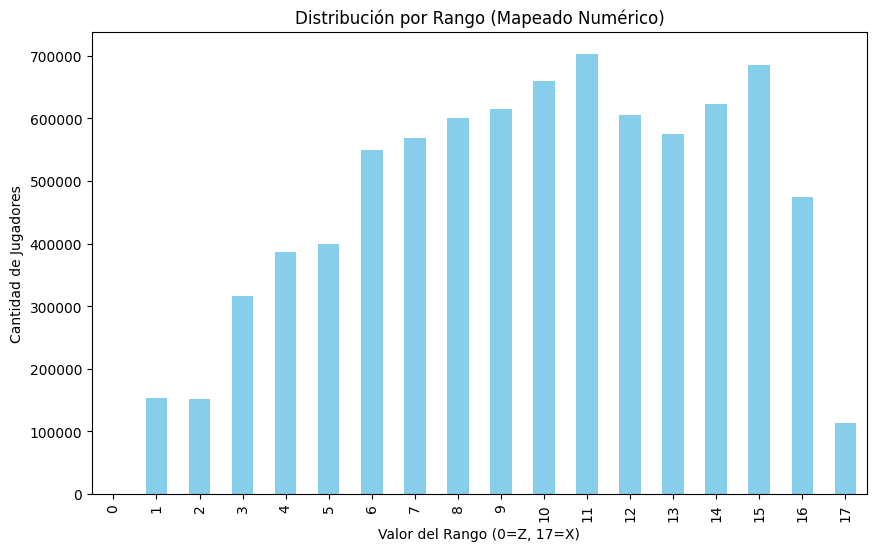

In [ ]:
# 7. GRÁFICO DE BARRAS (Distribución por Rango)
plt.figure(figsize=(10, 6))
df_final['rank_num'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribución por Rango (Mapeado Numérico)')
plt.xlabel('Valor del Rango (0=Z, 17=X)')
plt.ylabel('Cantidad de Jugadores')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


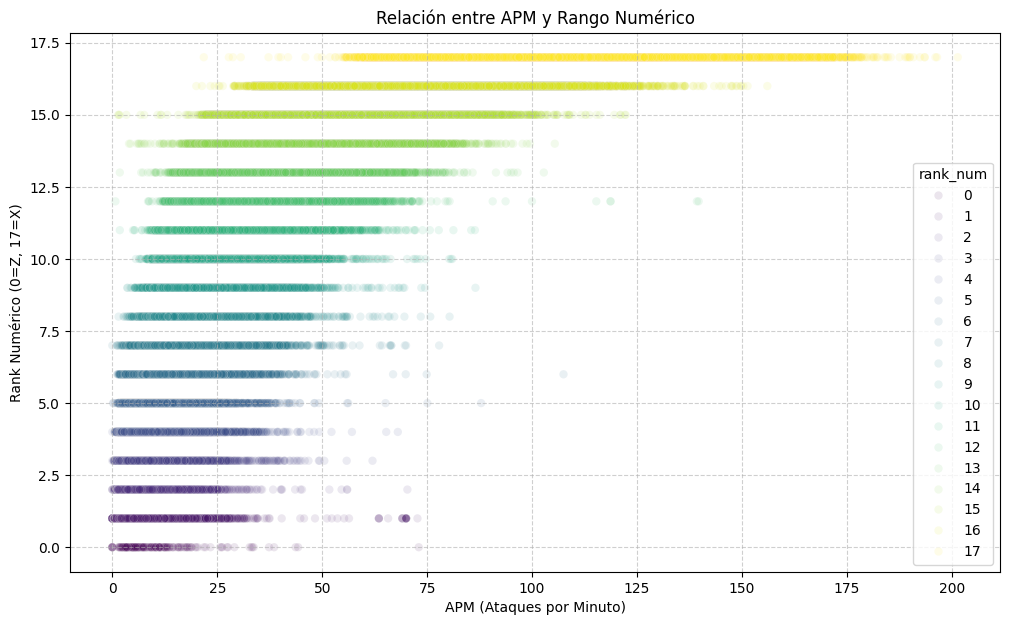

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='apm', y='rank_num', data=df_final, alpha=0.1, hue='rank_num', palette='viridis', legend='full')
plt.title('Relación entre APM y Rango Numérico')
plt.xlabel('APM (Ataques por Minuto)')
plt.ylabel('Rank Numérico (0=Z, 17=X)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_897/3981807069.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tlrank', y='apm', data=df_clean, order=orden_rangos, palette="Spectral")


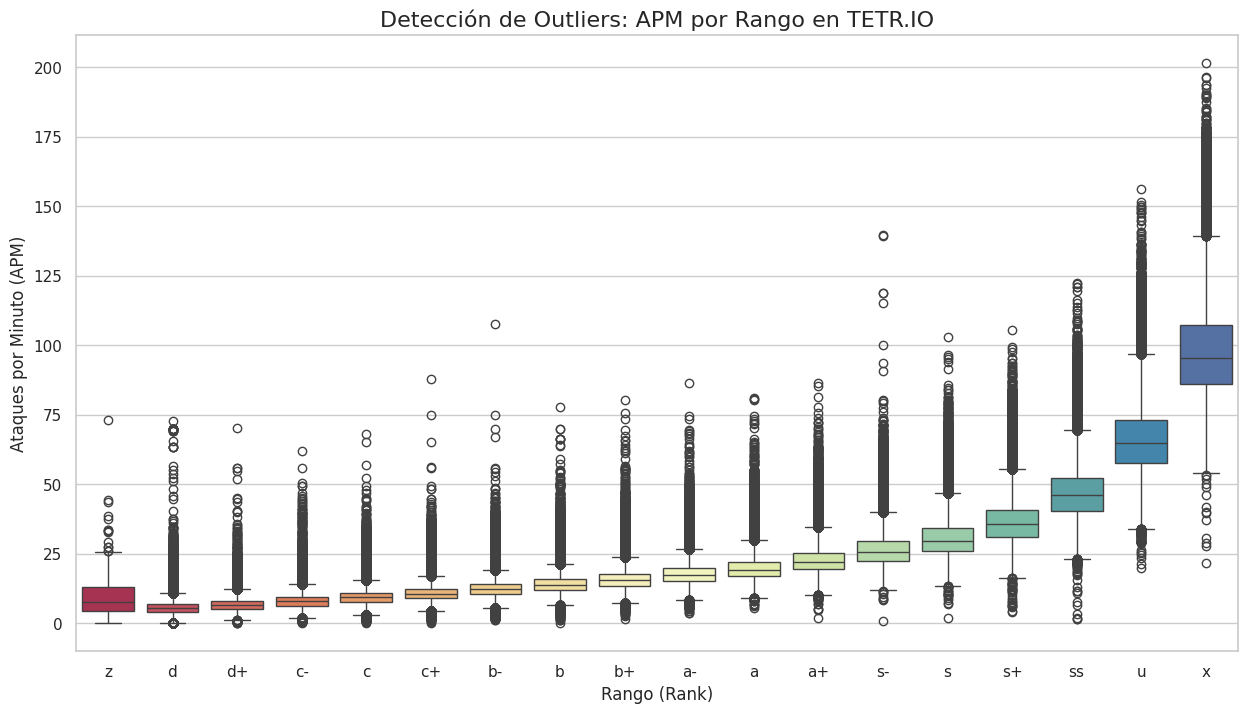

In [ ]:
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Usamos tlrank en el eje X para ver las categorías de rango
orden_rangos = ['z', 'd', 'd+', 'c-', 'c', 'c+', 'b-', 'b', 'b+', 'a-', 'a', 'a+', 's-', 's', 's+', 'ss', 'u', 'x']

sns.boxplot(x='tlrank', y='apm', data=df_clean, order=orden_rangos, palette="Spectral")


plt.title('Detección de Outliers: APM por Rango en TETR.IO', fontsize=16)
plt.xlabel('Rango (Rank)', fontsize=12)
plt.ylabel('Ataques por Minuto (APM)', fontsize=12)

plt.show()

/tmp/ipykernel_897/303707353.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


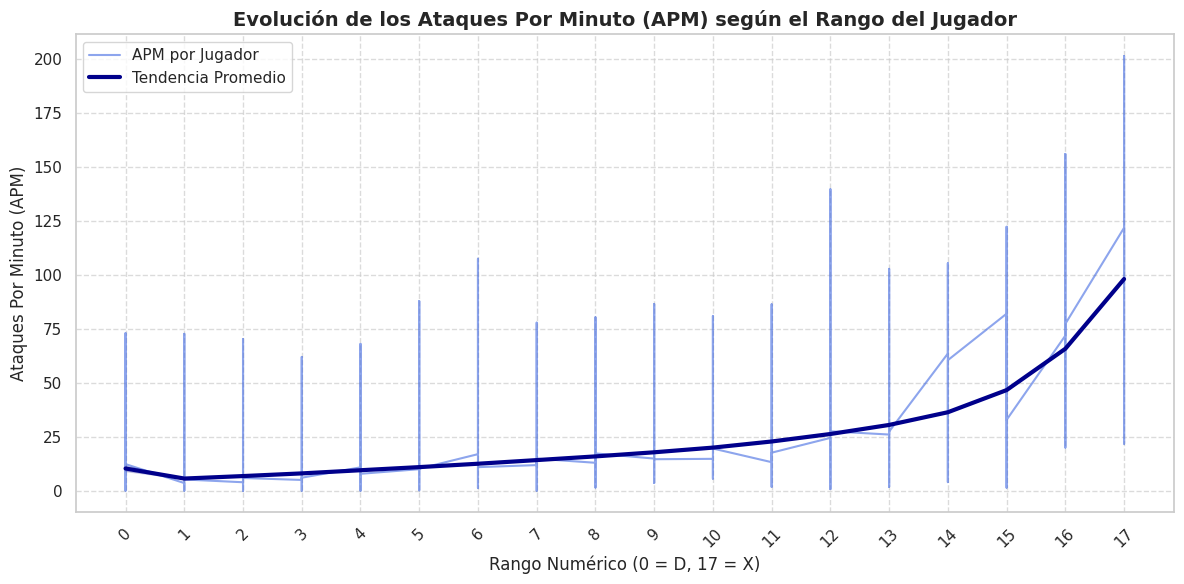

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


df_grafico = df_final.sort_values('rank_num')


xpoints = df_grafico['rank_num']
ypoints = df_grafico['apm']

plt.figure(figsize=(12, 6))


plt.plot(xpoints, ypoints, color='royalblue', linewidth=1.5, alpha=0.6, label='APM por Jugador')


sns.lineplot(data=df_grafico, x='rank_num', y='apm', color='darkblue', linewidth=3, label='Tendencia Promedio')


plt.title('Evolución de los Ataques Por Minuto (APM) según el Rango del Jugador', fontsize=14, fontweight='bold')
plt.xlabel('Rango Numérico (0 = D, 17 = X)', fontsize=12)
plt.ylabel('Ataques Por Minuto (APM)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, 18), rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

---
##  FASE 3 — Modelado

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


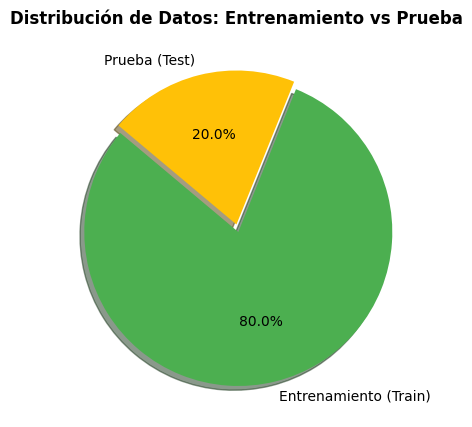

In [23]:
X_nuevo = df_final.drop('rank_num', axis=1)
y_nuevo = df_final['rank_num']


X_balanceado = np.log1p(X_nuevo)
y_balanceado = y_nuevo.copy()


X_train, X_test, y_train, y_test = train_test_split(X_balanceado, y_balanceado, test_size=0.2, random_state=42)


etiquetas = ['Entrenamiento (Train)', 'Prueba (Test)']
cantidades = [X_train.shape[0], X_test.shape[0]]
colores = ['#4CAF50', '#FFC107']

plt.figure(figsize=(5, 5))
plt.pie(cantidades, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=140, shadow=True, explode=(0.05, 0))
plt.title('Distribución de Datos: Entrenamiento vs Prueba', fontsize=12, fontweight='bold')
plt.show()

In [24]:
print("Entrenando HistGradientBoosting optimizado para rangos bajos...")

modelo_ajustado = HistGradientBoostingRegressor(
    loss='absolute_error',
    max_iter=150,
    learning_rate=0.08,
    random_state=42
)
modelo_ajustado.fit(X_train, y_train)


y_pred_raw = modelo_ajustado.predict(X_test)
rango_minimo_real = y_train.min()
y_pred_final = np.clip(y_pred_raw, a_min=rango_minimo_real, a_max=None)

Entrenando HistGradientBoosting optimizado para rangos bajos...


---
##  FASE 5 — Evaluacion


=== RENDIMIENTO TRAS AJUSTE DE RANGOS BAJOS ===
R2 (Explicación del modelo): 0.8926
MAE (Error promedio en rangos): 0.9932
RMSE: 1.3373


NameError: name 'sns' is not defined

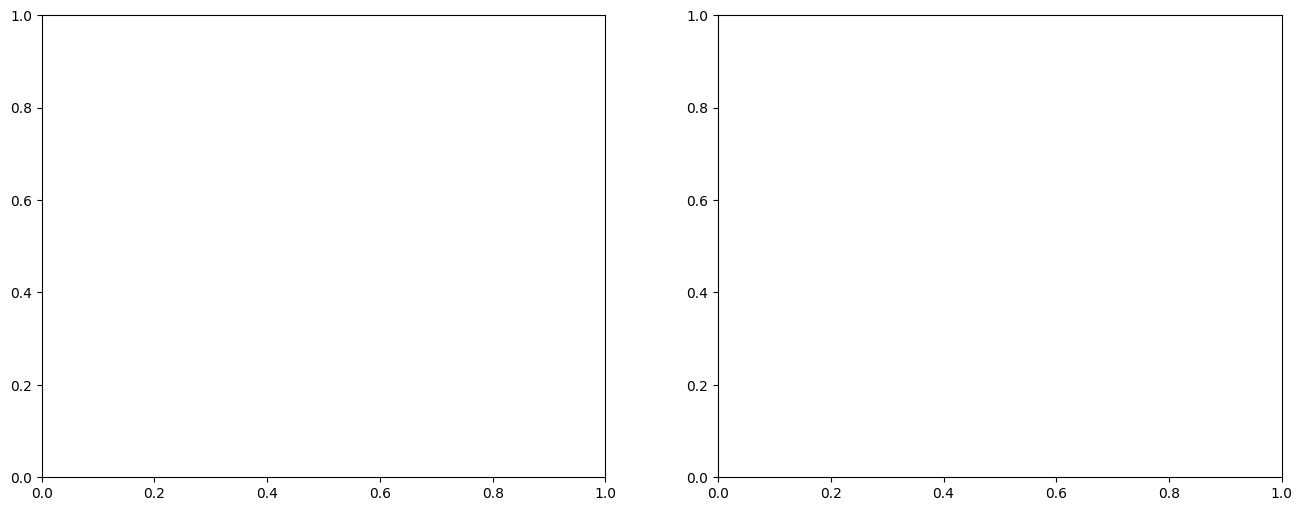

In [25]:
r2 = r2_score(y_test, y_pred_final)
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print("\n=== RENDIMIENTO TRAS AJUSTE DE RANGOS BAJOS ===")
print(f"R2 (Explicación del modelo): {r2:.4f}")
print(f"MAE (Error promedio en rangos): {mae:.4f}")
print(f"RMSE: {rmse:.4f}")



df_resultados = pd.DataFrame({'Rango Real': y_test.values, 'Rango Predicho': y_pred_final})
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(data=df_resultados, x='Rango Real', y='Rango Predicho', ax=axes[0], palette='Greens', fliersize=1)
axes[0].plot([-0.5, len(np.unique(y_test))-0.5], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title('Distribución Corregida por Rango Real', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rango Real del Jugador')
axes[0].set_ylabel('Rango Predicho')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)


resumen_rangos = df_resultados.groupby('Rango Real')['Rango Predicho'].agg(['mean', 'std']).reset_index()
axes[1].plot(resumen_rangos['Rango Real'], resumen_rangos['mean'], marker='o', color='#1b4d3e', lw=3, label='Nuevo Promedio Predicho')
axes[1].fill_between(resumen_rangos['Rango Real'], resumen_rangos['mean'] - resumen_rangos['std'], resumen_rangos['mean'] + resumen_rangos['std'], color='#1b4d3e', alpha=0.15)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
axes[1].set_title('Tendencia Corregida: Rango Real vs Promedio Predicho', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rango Real del Jugador')
axes[1].set_ylabel('Rango Predicho Promedio')
axes[1].set_xticks(resumen_rangos['Rango Real'])
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

---
##  FASE 6 — Conclusiones

El análisis sobre el dataset de TETR.IO confirmó que el APM es el predictor más fuerte del rango de un jugador, con una correlación de 0.82, seguido por PPS y adjusted_app. El modelo HistGradientBoostingRegressor entrenado logró un error promedio menor a 2 niveles de rango sobre 17 posibles, resultado aceptable considerando el desbalance natural de jugadores concentrados en rangos medios. Como trabajo futuro se recomienda incorporar glicko y tr como variables adicionales y explorar un enfoque de clasificación multiclase para predecir el rango exacto.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


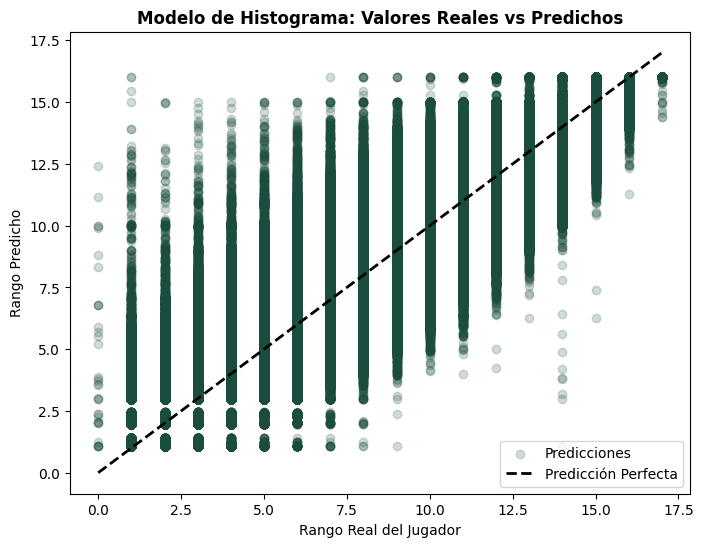

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.2, color='#1b4d3e', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Predicción Perfecta')
plt.title('Modelo de Histograma: Valores Reales vs Predichos', fontsize=12, fontweight='bold')
plt.xlabel('Rango Real del Jugador')
plt.ylabel('Rango Predicho')
plt.legend()
plt.show()

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [30]:
# =====================================================================
# 1. MUESTREO Y PREPARACIÓN PARA K-MEANS
# Tomamos una muestra
df_sample = df_final.sample(n=100000, random_state=42)
X_cluster = df_sample[['apm', 'pps', 'raw_app', 'adjusted_app']]

# Escalado obligatorio para algoritmos (K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


Calculando inercias para el gráfico de codo (esto puede tomar unos segundos)...


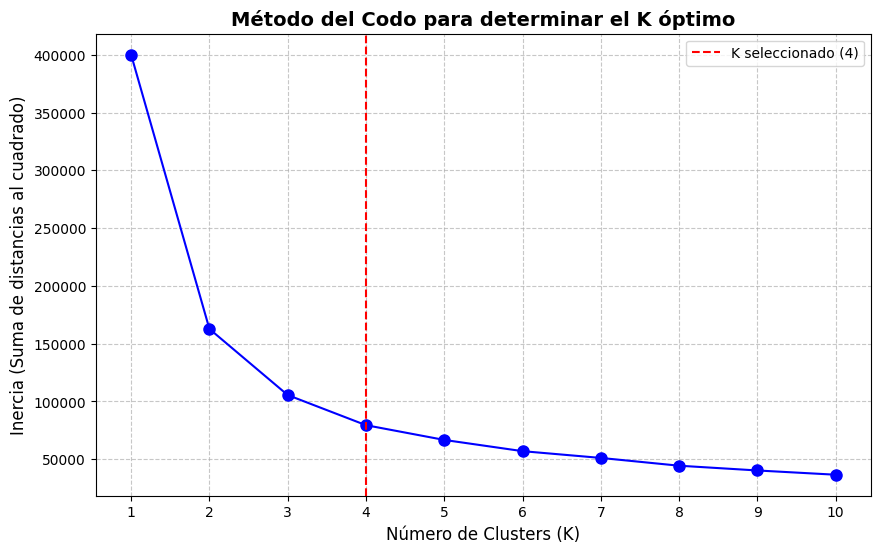

In [31]:
# =====================================================================
# 1.5 ANÁLISIS DEL MÉTODO DEL CODO

print("Calculando inercias para el gráfico de codo (esto puede tomar unos segundos)...")

inercia = []
rango_k = range(1, 11) # Probaremos de 1 a 10 clusters

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X_scaled)
    inercia.append(kmeans_temp.inertia_)

# Configuración del gráfico
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='-', color='b', markersize=8)


plt.title('Método del Codo para determinar el K óptimo', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (Suma de distancias al cuadrado)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.7)


plt.axvline(x=4, color='r', linestyle='--', label='K seleccionado (4)')
plt.legend()


plt.show()

In [32]:
# =====================================================================
# 2. ENTRENAMIENTO DEL MODELO DE CLUSTERING (K-MEANS)


# Entrenamos con K=4 basándonos en el análisis del Método del Codo
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init='auto')
cluster_asignado = kmeans_final.fit_predict(X_scaled)

# Asignamos el cluster de vuelta al DataFrame muestra
df_sample['cluster_estilo'] = cluster_asignado


nombres_perfiles = {
    0: "0. Principiante/Casual",
    1: "1. Avanzado en Desarrollo",
    2: "2. Especialista/Táctico",
    3: "3. Élite/Maestro"
}
df_sample['nombre_perfil'] = df_sample['cluster_estilo'].map(nombres_perfiles)

print("=== COPIANDO DIAGNÓSTICO DE PERFILES REALS ===")
perfiles = df_sample.groupby('cluster_estilo')[['apm', 'pps', 'raw_app', 'adjusted_app', 'rank_num']].mean()
print(perfiles.round(2))

=== COPIANDO DIAGNÓSTICO DE PERFILES REALS ===
                  apm   pps  raw_app  adjusted_app  rank_num
cluster_estilo                                              
0               21.62  1.15     0.31          0.21     10.36
1               72.14  2.13     0.57          0.38     15.93
2               10.90  0.85     0.21          0.14      5.61
3               38.93  1.44     0.45          0.30     13.63


In [33]:
# =====================================================================
# 3. GENERACIÓN DEL DATASET ESTRATIFICADO DE QA

muestra_por_rango = 500
df_qa = pd.DataFrame()

print("\nGenerando Set de Datos de QA estratificado por los 17 rangos...")

# Extraemos muestras balanceadas (500 por cada uno de los 17 rangos)
for rango in df_final['rank_num'].unique():
    df_rango_especifico = df_final[df_final['rank_num'] == rango]

    if len(df_rango_especifico) >= muestra_por_rango:
        df_muestra = df_rango_especifico.sample(n=muestra_por_rango, random_state=42)
    else:
        df_muestra = df_rango_especifico

    df_qa = pd.concat([df_qa, df_muestra], axis=0)




Generando Set de Datos de QA estratificado por los 17 rangos...


In [34]:
# =====================================================================
# 4. PREDICCIÓN Y ENSAMBLADO FINAL PARA ENVIAR A QA / POWER BI

X_qa = df_qa[['apm', 'pps', 'raw_app', 'adjusted_app']]


X_qa_scaled_log = np.log1p(X_qa).fillna(0)

# Escalado estándar para el K-Means
X_qa_scaled_cluster = scaler.transform(X_qa)

# Aplicamos las predicciones del modelo HistGradientBoosting
df_qa['rango_predicho'] = modelo_ajustado.predict(X_qa_scaled_log)
df_qa['rango_predicho'] = np.clip(df_qa['rango_predicho'], a_min=0, a_max=17).round(2)

# Asignamos los clusters correspondientes al set de QA
df_qa['cluster_estilo'] = kmeans_final.predict(X_qa_scaled_cluster)
df_qa['nombre_perfil'] = df_qa['cluster_estilo'].map(nombres_perfiles)

# Guardamos el archivo final
df_qa.to_csv('dataset_pruebas_QA.csv', index=False)

print(f"\n✅ ¡Proceso terminado! Archivo 'dataset_pruebas_QA.csv' listo.")
print("\nVerificación de balance en el archivo exportado:")
print(df_qa['rank_num'].value_counts().sort_index())

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)



✅ ¡Proceso terminado! Archivo 'dataset_pruebas_QA.csv' listo.

Verificación de balance en el archivo exportado:
rank_num
0     200
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
10    500
11    500
12    500
13    500
14    500
15    500
16    500
17    500
Name: count, dtype: int64
